In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

from energy_thief.envs import GridThiefEnv, ACTION_NAMES
from energy_thief.agents import QLearningAgent

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

In [2]:
env = GridThiefEnv(seed=1)
print(f"states: {env.n_states}   actions: {env.n_actions}")
print(f"consumers: {env.consumers}")
print(f"action names: {ACTION_NAMES}")
print("divertible slack per (phase, consumer):")
print(env.slack)
print(f"monitoring sensitivity per phase: {np.round(env.sens, 3)}")
print(env.render())

states: 36   actions: 7
consumers: ('C1', 'C2', 'C3')
action names: ['skim-C1', 'overdraw-C1', 'skim-C2', 'overdraw-C2', 'skim-C3', 'overdraw-C3', 'secure']
divertible slack per (phase, consumer):
[[3 1 0]
 [1 0 2]
 [0 2 0]
 [1 0 0]]
monitoring sensitivity per phase: [0.04 0.08 0.12 0.16]
t=0   phase=0 (sens=0.04)  surplus=0/8  flows[C1:4(+3) C2:3(+1) C3:3(+0)]


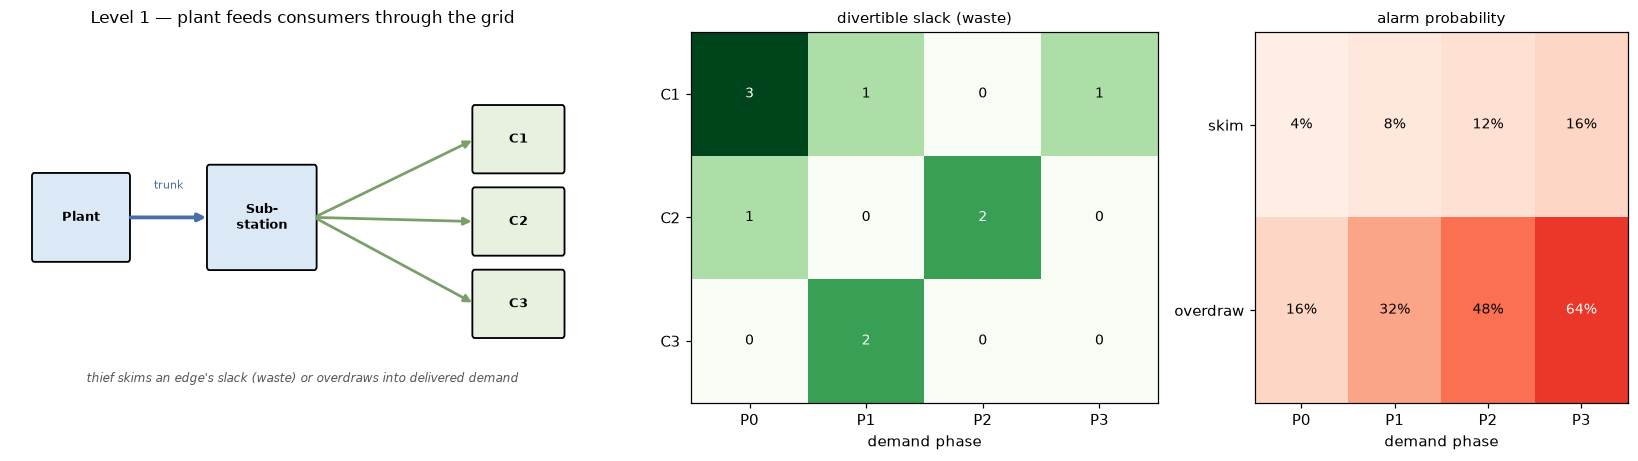

In [3]:
fig, (axS, axK, axR) = plt.subplots(1, 3, figsize=(15, 4.3),
                                    gridspec_kw={"width_ratios": [1.25, 1, 0.8]})
n = env.n_consumers

# Panel 1: network schematic
axS.set_xlim(0, 10); axS.set_ylim(0, n + 1.5); axS.axis("off")
def box(x, y, w, h, label, fc):
    axS.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle="round,pad=0.04",
                  fc=fc, ec="black", lw=1.2))
    axS.text(x, y, label, ha="center", va="center", fontsize=8.5, weight="bold")
ymid = (n + 1.5) / 2
box(1.2, ymid, 1.6, 1.0, "Plant", "#dbe9f6")
box(4.3, ymid, 1.8, 1.2, "Sub-\nstation", "#dbe9f6")
axS.annotate("", xy=(3.4, ymid), xytext=(2.0, ymid),
             arrowprops=dict(arrowstyle="-|>", lw=2.5, color="#4a6fa5"))
axS.text(2.7, ymid + 0.35, "trunk", ha="center", fontsize=7.5, color="#4a6fa5")
for i, c in enumerate(env.consumers):
    y = n - i + 0.2
    box(8.7, y, 1.5, 0.75, c, "#e8f0e0")
    axS.annotate("", xy=(7.95, y), xytext=(5.2, ymid),
                 arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#7aa06a"))
axS.set_title("Level 1 — plant feeds consumers through the grid", fontsize=11)
axS.text(5.0, 0.25, "thief skims an edge's slack (waste) or overdraws into delivered demand",
         ha="center", fontsize=8, style="italic", color="#555")

# Panel 2: divertible slack per (consumer x phase)
axK.imshow(env.slack.T, cmap="Greens", aspect="auto", vmin=0, vmax=env.slack.max())
for i in range(n):
    for ph in range(env.n_phase):
        axK.text(ph, i, str(env.slack[ph, i]), ha="center", va="center", fontsize=9,
                 color="white" if env.slack[ph, i] > env.slack.max()*0.6 else "black")
axK.set_xticks(range(env.n_phase)); axK.set_xticklabels([f"P{p}" for p in range(env.n_phase)])
axK.set_yticks(range(n)); axK.set_yticklabels(env.consumers)
axK.set_xlabel("demand phase"); axK.set_title("divertible slack (waste)", fontsize=10)

# Panel 3: skim vs overdraw alarm probability per phase
risk = np.array([
    [min(1.0, env.sens[ph] * env.base_divert) for ph in range(env.n_phase)],
    [min(1.0, env.sens[ph] * (env.base_divert + env.shortfall_weight * env.overdraw_extra))
     for ph in range(env.n_phase)],
])
axR.imshow(risk, cmap="Reds", aspect="auto", vmin=0, vmax=1)
for r in range(2):
    for ph in range(env.n_phase):
        axR.text(ph, r, f"{risk[r,ph]*100:.0f}%", ha="center", va="center", fontsize=9,
                 color="white" if risk[r, ph] > 0.5 else "black")
axR.set_xticks(range(env.n_phase)); axR.set_xticklabels([f"P{p}" for p in range(env.n_phase)])
axR.set_yticks([0, 1]); axR.set_yticklabels(["skim", "overdraw"])
axR.set_xlabel("demand phase"); axR.set_title("alarm probability", fontsize=10)
fig.tight_layout(); plt.show()

In [4]:
def evaluate(env, agent, n_episodes=1000):
    rets = np.empty(n_episodes)
    for ep in range(n_episodes):
        s, _ = env.reset()
        done, g = False, 0.0
        while not done:
            a = agent.select_action(s, greedy=True)
            s, r, term, trunc, _ = env.step(a)
            g, done = g + r, term or trunc
        rets[ep] = g
    return rets.mean(), rets.std()


def train(env, n_episodes, seed, eval_env=None, eval_every=250, eval_episodes=50, **kw):
    agent = QLearningAgent(env.n_states, env.action_space.n, seed=seed, **kw)
    returns = np.empty(n_episodes)
    epsilons = np.empty(n_episodes)
    eval_x, eval_y = [], []
    for ep in range(n_episodes):
        s, _ = env.reset()
        done, g = False, 0.0
        while not done:
            a = agent.select_action(s)
            s2, r, term, trunc, _ = env.step(a)
            agent.update(s, a, r, s2, term)
            s, g, done = s2, g + r, term or trunc
        returns[ep] = g
        epsilons[ep] = agent.epsilon
        agent.end_episode()
        if eval_env is not None and (ep + 1) % eval_every == 0:
            m, _ = evaluate(eval_env, agent, eval_episodes)
            eval_x.append(ep + 1); eval_y.append(m)
    return agent, returns, np.array(eval_x), np.array(eval_y), epsilons

In [5]:
N_EPISODES = 8000
SEEDS = range(5)
HP = dict(alpha=0.1, gamma=0.99, epsilon_decay=0.999)

curves, eval_curves, agents = [], [], []
eval_x, epsilons = None, None
for seed in SEEDS:
    agent, returns, ex, ey, eps = train(
        GridThiefEnv(seed=1), N_EPISODES, seed=seed, eval_env=GridThiefEnv(seed=1), **HP)
    curves.append(returns); eval_curves.append(ey); agents.append(agent)
    eval_x = ex
    epsilons = eps if epsilons is None else epsilons
curves = np.array(curves); eval_curves = np.array(eval_curves)
print("training done:", curves.shape)

training done: (5, 8000)


## Learning curve

Return per episode, averaged over seeds (band = ±1 std, 100-episode moving average).

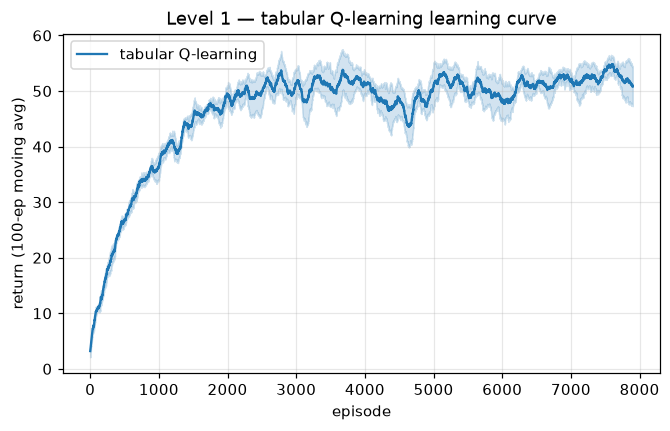

In [6]:
def moving_average(x, w=100):
    return np.convolve(x, np.ones(w) / w, mode="valid")

smoothed = np.array([moving_average(c) for c in curves])
mean, std = smoothed.mean(0), smoothed.std(0)
x = np.arange(smoothed.shape[1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, mean, color="C0", label="tabular Q-learning")
ax.fill_between(x, mean - std, mean + std, color="C0", alpha=0.2)
ax.set_xlabel("episode"); ax.set_ylabel("return (100-ep moving avg)")
ax.set_title("Level 1 — tabular Q-learning learning curve")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## Greedy evaluation return

The greedy policy (no exploration), evaluated every 250 episodes — the smooth curve
that actually matters.

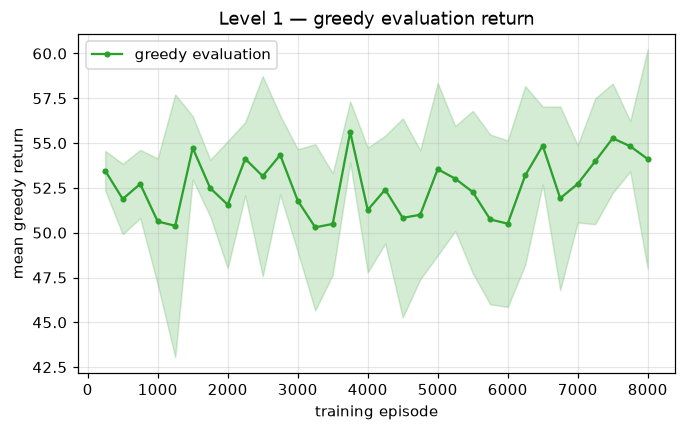

final greedy return: +54.11 ± 6.13


In [7]:
ev_mean, ev_std = eval_curves.mean(0), eval_curves.std(0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eval_x, ev_mean, color="C2", marker="o", ms=3, label="greedy evaluation")
ax.fill_between(eval_x, ev_mean - ev_std, ev_mean + ev_std, color="C2", alpha=0.2)
ax.set_xlabel("training episode"); ax.set_ylabel("mean greedy return")
ax.set_title("Level 1 — greedy evaluation return")
ax.legend(); ax.grid(alpha=0.3)
plt.show()
print(f"final greedy return: {ev_mean[-1]:+.2f} ± {ev_std[-1]:.2f}")

## Exploration schedule

$\varepsilon$ annealed geometrically from 1 to its floor $\varepsilon_{\min}$.

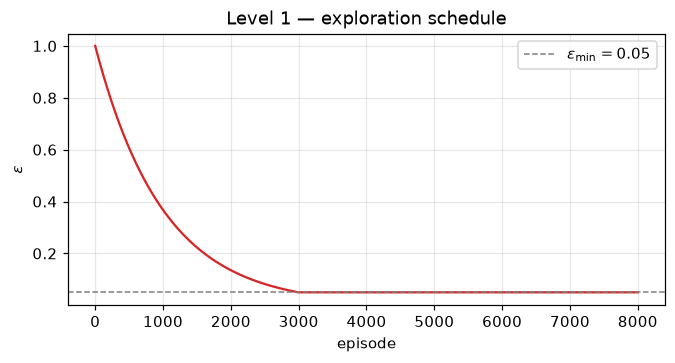

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(np.arange(len(epsilons)), epsilons, color="C3")
ax.axhline(agents[0].epsilon_min, ls="--", color="grey", lw=1,
           label=fr"$\varepsilon_{{\min}} = {agents[0].epsilon_min}$")
ax.set_xlabel("episode"); ax.set_ylabel(r"$\varepsilon$")
ax.set_title("Level 1 — exploration schedule")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## The learned policy

The state is just $(\text{phase}, \text{surplus})$, so the greedy policy fits in one
table. Cells show the chosen action (**sk**$c$ = skim consumer $c$, **ov**$c$ =
overdraw, **S** = secure). Read it against the slack map above: the thief **skims the
consumer edge with the most slack in each phase**, and **secures** when the grid is
tight (little slack, high sensitivity) or the surplus is worth banking.

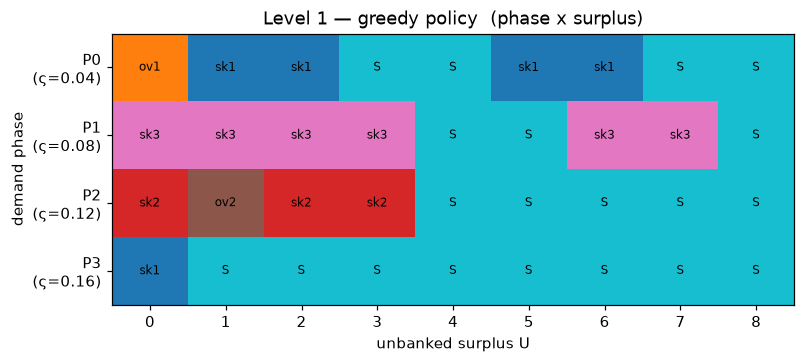

In [9]:
def short(a):
    if a == env.SECURE:
        return "S"
    c, ov = divmod(a, 2)
    return f"{'ov' if ov else 'sk'}{c+1}"

policy = agents[0].greedy_policy().reshape(env.n_phase, env.surplus_max + 1)
cmap = plt.get_cmap("tab10", env.n_actions)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.imshow(policy, cmap=cmap, vmin=0, vmax=env.n_actions - 1, aspect="auto")
for P in range(env.n_phase):
    for U in range(env.surplus_max + 1):
        ax.text(U, P, short(policy[P, U]), ha="center", va="center", fontsize=8)
ax.set_xticks(range(env.surplus_max + 1)); ax.set_yticks(range(env.n_phase))
ax.set_yticklabels([f"P{P}\n(ς={env.sens[P]:.2f})" for P in range(env.n_phase)])
ax.set_xlabel("unbanked surplus U"); ax.set_ylabel("demand phase")
ax.set_title("Level 1 — greedy policy  (phase x surplus)")
plt.show()

## A single shift, step by step

One greedy episode. Top: the demand phase drifting. Middle: the surplus, with secures
($\vee$) and alarms ($\times$). Bottom: **which consumer edge the thief redirects flow
from** each step (● skim, ▲ overdraw) — watch it follow the slack from phase to phase.

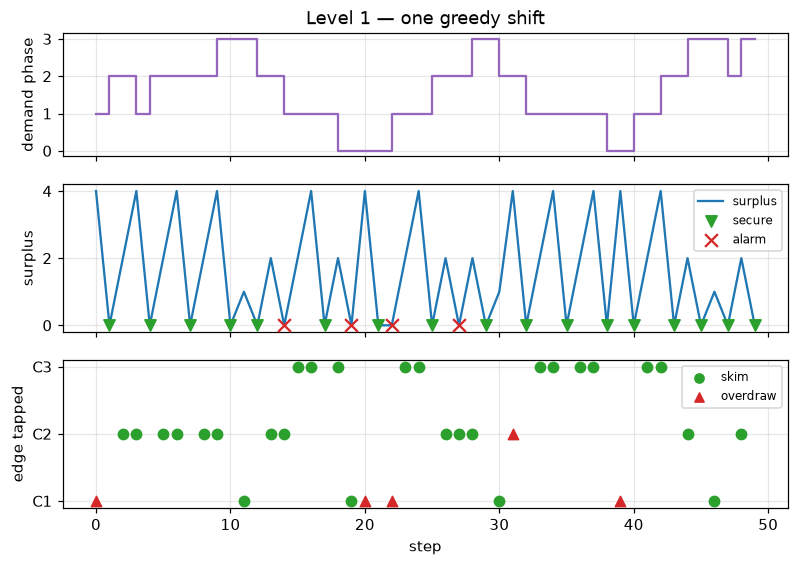

In [10]:
def greedy_trace(env, agent):
    s, _ = env.reset()
    phases, surplus, secures, alarms, taps = [], [], [], [], []
    done, t = False, 0
    while not done:
        a = agent.select_action(s, greedy=True)
        s, r, term, trunc, info = env.step(a)
        phases.append(info["phase"]); surplus.append(info["surplus"])
        if info["banked"] > 0: secures.append(t)
        if info["alarm"]: alarms.append(t)
        if info["tapped"] >= 0: taps.append((t, info["tapped"], a % 2 == 1))
        done, t = term or trunc, t + 1
    return np.array(phases), np.array(surplus), secures, alarms, taps

phases, surplus, secures, alarms, taps = greedy_trace(GridThiefEnv(seed=7), agents[0])
steps = np.arange(len(phases))

fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(8.5, 5.6), sharex=True,
                                 gridspec_kw={"height_ratios": [1, 1.2, 1.2]})
a1.step(steps, phases, where="post", color="C4"); a1.set_ylabel("demand phase")
a1.set_yticks(range(env.n_phase)); a1.grid(alpha=0.3)
a1.set_title("Level 1 — one greedy shift")

a2.plot(steps, surplus, color="C0", label="surplus")
a2.scatter(secures, surplus[secures], marker="v", color="C2", s=55, zorder=3, label="secure")
if alarms:
    a2.scatter(alarms, np.zeros(len(alarms)), marker="x", color="C3", s=70, zorder=3, label="alarm")
a2.set_ylabel("surplus"); a2.grid(alpha=0.3); a2.legend(loc="upper right", fontsize=8)

for t, c, ov in taps:
    a3.scatter(t, c, marker="^" if ov else "o",
               color="C3" if ov else "C2", s=45, zorder=3)
a3.set_yticks(range(env.n_consumers)); a3.set_yticklabels(env.consumers)
a3.set_ylabel("edge tapped"); a3.set_xlabel("step"); a3.grid(alpha=0.3)
a3.scatter([], [], marker="o", color="C2", label="skim"); a3.scatter([], [], marker="^", color="C3", label="overdraw")
a3.legend(loc="upper right", fontsize=8)
plt.show()